# Evaluating ML Models on Injection Moulding Dataset #

Aditya Jyotis

#### Imports ####

In [29]:
import pandas as pd
import os
import numpy as np
import re
import matplotlib as plt
import seaborn as sns
import matplotlib.pyplot as pyplt
import math

#### Read raw dataset ####

First 78 rows are skipped since they contain the legend and other information.

In [30]:
script_dir = os.getcwd()
rel_path = "raw"

# UNCOMMENT IF FILE HAS LEGEND OR OTHER PREAMBLE
#dataset = pd.read_excel(os.path.join(script_dir, rel_path, "data_injection_molding.xlsx"), skiprows=77)
dataset = pd.read_excel(os.path.join(script_dir, rel_path, "eval_set_1_no_target.xlsx"))
dataset_copy = dataset.copy(deep=True)


dataset.info()
dataset.head()
dataset.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 613 entries, 0 to 612
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   SZx [Sch]      613 non-null    int64         
 1   Datum [ ]      613 non-null    datetime64[ns]
 2   Zeit [ ]       613 non-null    object        
 3   StZx [Stk]     613 non-null    int64         
 4   ZSx [s]        613 non-null    float64       
 5   APHu [bar]     613 non-null    int64         
 6   ACPx [cm³]     613 non-null    float64       
 7   ZDx [s]        613 non-null    float64       
 8   ZUs [s]        613 non-null    float64       
 9   GEx [kWh]      613 non-null    float64       
 10  GPx [kW]       613 non-null    float64       
 11  HPx [kW]       613 non-null    float64       
 12  HEx [kWh]      613 non-null    float64       
 13  MPx [kW]       613 non-null    float64       
 14  ESPx [kWh/kg]  613 non-null    float64       
 15  H16x [°C]      613 non-

,SZx [Sch],Datum [ ],StZx [Stk],ZSx [s],APHu [bar],ACPx [cm³],ZDx [s],ZUs [s],GEx [kWh],GPx [kW],...,HEx [kWh],MPx [kW],ESPx [kWh/kg],H16x [°C],H15x [°C],ZEx [s],H10x [°C],H12x [°C],H9x [°C],H11x [°C]
count,613.000000,613,613.000000,613.000000,613.0,613.000000,613.000000,613.000000,613.000000,613.000000,...,613.000000,613.000000,613.000000,613.000000,613.000000,613.000000,613.000000,613.000000,613.000000,613.000000
mean,3176.845024,2024-07-25 15:58:26.035889152,12158.199021,0.728157,0.0,4.191011,2.684747,19.371713,0.023519,3.212659,...,0.018261,0.272545,0.123263,187.901468,192.267700,4.661289,422.002773,431.317292,421.986134,429.485481
min,3.000000,2024-07-25 00:00:00,0.000000,0.680000,0.0,3.870000,2.360000,19.250000,0.021000,2.280000,...,0.015000,0.230000,0.108000,183.900000,191.400000,4.570000,415.400000,419.600000,419.700000,418.300000
25%,1693.000000,2024-07-25 00:00:00,6340.000000,0.720000,0.0,4.160000,2.660000,19.310000,0.023000,2.920000,...,0.018000,0.230000,0.120000,187.900000,192.200000,4.640000,420.000000,425.000000,420.000000,425.000000
50%,3212.000000,2024-07-26 00:00:00,12416.000000,0.730000,0.0,4.220000,2.690000,19.330000,0.023000,3.150000,...,0.018000,0.230000,0.123000,187.900000,192.300000,4.660000,420.100000,426.200000,420.100000,425.400000
75%,4697.000000,2024-07-26 00:00:00,18056.000000,0.740000,0.0,4.260000,2.720000,19.360000,0.024000,3.420000,...,0.019000,0.230000,0.126000,188.000000,192.300000,4.680000,424.900000,439.100000,425.000000,436.100000
max,6122.000000,2024-07-26 00:00:00,23588.000000,0.820000,0.0,4.340000,2.930000,20.440000,0.027000,7.320000,...,0.022000,3.400000,0.142000,188.400000,192.800000,4.750000,437.700000,440.200000,425.300000,438.700000
std,1762.555334,NaN,6845.891977,0.019158,0.0,0.100249,0.067430,0.189933,0.000952,0.514628,...,0.000969,0.340666,0.004770,0.361163,0.208874,0.032961,2.549627,7.143757,2.441168,6.296376


## Chapter 1: Dataset clean-up ##

Search for null values and duplicate rows

In [31]:
print(dataset.isnull().sum())
print("----------------------------------------------------")
print(dataset.duplicated().sum())



SZx [Sch]        0
Datum [ ]        0
Zeit [ ]         0
StZx [Stk]       0
ZSx [s]          0
APHu [bar]       0
ACPx [cm³]       0
ZDx [s]          0
ZUs [s]          0
GEx [kWh]        0
GPx [kW]         0
HPx [kW]         0
HEx [kWh]        0
MPx [kW]         0
ESPx [kWh/kg]    0
H16x [°C]        0
H15x [°C]        0
ZEx [s]          0
H10x [°C]        0
H12x [°C]        0
H9x [°C]         0
H11x [°C]        0
dtype: int64
----------------------------------------------------
0


No null values found, except for in the column 'ASZ [Sch]', which makes sense because that is the column marking defective parts with an asterisk.
Moreover, no duplicated rows found.

#### Plot histogram ####

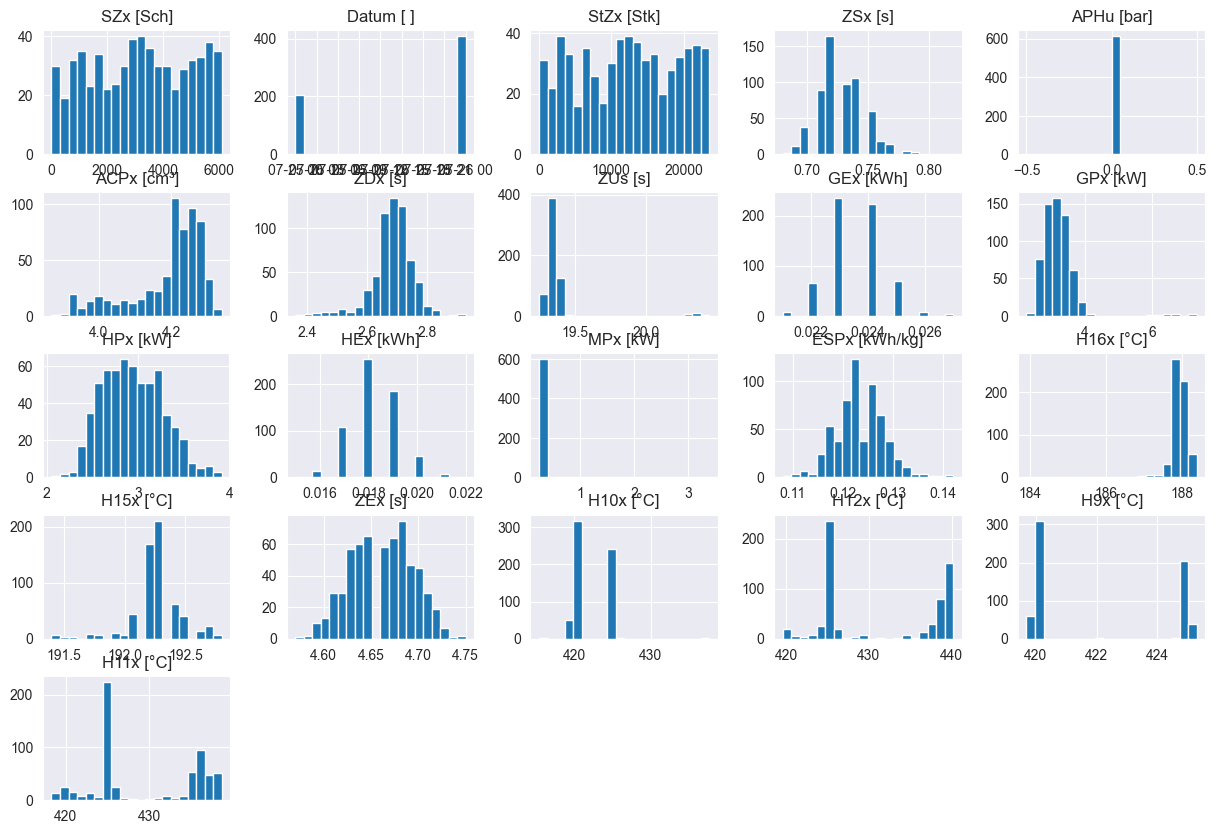

In [32]:
histogram = dataset.hist(bins=20, figsize=(15, 10))


#### Detect Outliers ####

The histograms imply we have erroneous values that are either much larger or much smaller than the majority of data points. Hence we search for outliers using the interquartile range.

In [33]:
def detect_outliers(dataset):
    numeric_cols = dataset.select_dtypes(include=[np.number])

    output_data = []

    for col in numeric_cols:
        Q1 = dataset[col].quantile(0.25)
        Q3 = dataset[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        num_outliers = dataset[(dataset[col] < lower_bound) | (dataset[col] > upper_bound)].shape[0]
        pct_outliers = (num_outliers / len(dataset)) * 100

        # Store results in above defined array
        output_data.append({
            'Column': col,
            'Lower Bound': round(lower_bound, 2),
            'Upper Bound': round(upper_bound, 2),
            'Outlier Count': num_outliers,
            'Percentage Outliers': round(pct_outliers, 2),
        })
    return pd.DataFrame(output_data).sort_values(by='Outlier Count', ascending=False)

outliers = detect_outliers(dataset)
print(outliers)


           Column  Lower Bound  Upper Bound  Outlier Count  \
14      H15x [°C]       192.05       192.45            127   
13      H16x [°C]       187.75       188.15            111   
4      ACPx [cm³]         4.01         4.41             61   
5         ZDx [s]         2.57         2.81             44   
6         ZUs [s]        19.24        19.44             24   
10      HEx [kWh]         0.02         0.02             23   
7       GEx [kWh]         0.02         0.03             19   
11       MPx [kW]         0.23         0.23             14   
2         ZSx [s]         0.69         0.77             13   
12  ESPx [kWh/kg]         0.11         0.14              9   
8        GPx [kW]         2.17         4.17              9   
15        ZEx [s]         4.58         4.74              3   
16      H10x [°C]       412.65       432.25              1   
3      APHu [bar]         0.00         0.00              0   
0       SZx [Sch]     -2813.00      9203.00              0   
1      S

#### Analysis of IQR Results ####

While the IQR values show outlier counts that lookk alarming, further introspection reveals some interesting information.

##### 1. H16x and H15x showing high variance
* 21.71% of values for H16x are outliers
* Sensor has units degrees Celsius so most likely a temperature measurement
* Unsure whether to remove outliers
    * 21.7% is a large part of the dataset
    * Either sensor is faulty, in which case all values of that column should be discarded
    * Alternatively this actually describes machine behaviour, and must be retained
* Final decision to retain data, as this seems too large a proportion to be random errors, and hence must describe machine behaviour

##### 2. ACPx [cm³] showing high variance #####
* 12.2% of values are outliers
* Measure of cushion volume
* "Insufficient cushion provides inadequate packing pressure, while oversized cushions increase risks of degraded plastic entering the part" [source][1]
* Since these are important data points, we retain all of these values despite the outliers.

##### 3. HEx and MPx have extremely tight bounds #####
* Lower bound and upper bound are the same, meaning normal range has been squished into one value
* Just means machine is very consistent with regard to these metrics. These outlier flags are ignored.

##### 4. SZx and StZx have meaningless bounds
* Schüsszähler and Stückzähler
* They are counters
* The lower bounds are negative, despite being counters, meaning the features are linearly increasing over time
* These values are to be dropped from the dataset, since the ML model cannot gain any useful insights out of these.

##### 5. ZDx, ZUs, ZSx, and ZEx show some variance
* All temporal features
* Outliers make up less than 5%
* Bounds are tight meaning they could be just normal machine jitter



[1]: <https://baiwemolding.com/what-is-the-cushion-in-injection-molding/>


#### Z-Score ####

However, the IQR method does not give us a complete picture. We know the percentage of outlier values, but we do not know just how far from the mean they are. Hence we look for statistical outliers using the Z-Score.

In [34]:
def find_extremes(dataset, top_n = 20):
    numeric_cols = dataset.select_dtypes(include=[np.number])

    z_scores = numeric_cols.apply(lambda x: np.abs((x - x.mean()) / x.std()))

    dataset['max_z_score'] = z_scores.max(axis=1)

    extreme_rows = dataset.sort_values(by=['max_z_score'], ascending=False).head(top_n)

    return extreme_rows

extremes = find_extremes(dataset)
print(extremes)
dataset = dataset.drop(columns=['max_z_score'])

     SZx [Sch]  Datum [ ]  Zeit [ ]  StZx [Stk]  ZSx [s]  APHu [bar]  \
0            3 2024-07-25  11:43:13           0     0.74           0   
1           13 2024-07-25  11:46:36           0     0.72           0   
58         696 2024-07-25  15:45:23        2476     0.74           0   
66         768 2024-07-25  16:15:09        2664     0.77           0   
20         216 2024-07-25  13:08:50         728     0.74           0   
362       3657 2024-07-26  07:47:34       14152     0.72           0   
369       3750 2024-07-26  08:19:45       14448     0.73           0   
18         212 2024-07-25  13:07:29         728     0.74           0   
370       3765 2024-07-26  08:25:06       14472     0.71           0   
19         213 2024-07-25  13:07:49         728     0.71           0   
372       3776 2024-07-26  08:34:41       14480     0.69           0   
64         758 2024-07-25  16:06:36        2652     0.75           0   
516       5305 2024-07-26  16:55:08       20368     0.74        

There is a row with a max z-score of 51.07, which is a big red flag, sicne it means the value is 51 standard deviations away from the mean.

Digging deeper into that row, we find that the error stems from the column 'ZUs [s]', which denotes cycle time. Most of the other values are in the 20s of seconds. Row 3008 shows a ZUs of 0.88. This is physically impossible, since the machine cannot complete a full moulding cycle in less than a second. Moreover, the energy consumption is nearly zero, which is not possible if the motors and heaters were running. This means that this is likely caused by a sensor glitch or the data logging software accidentally recording a nonexistent cycle.

A second interesting anomaly can be seen in row 178, where we see a ZDx, or dosing time of 0 seconds. This would mean no material was moved through the extruder, meaning no part was produced.

Lastly, we see that for the lower indexed rows (0, 1, 10, 178, 179, etc.), the H16x values are below the lower bound found in the IQR report. These rows also have a low SZx, or shot counter values. It can be implied that the machine hasn't reached thermal equilibrium yet, and the fact that the temperatures are low relative to the steady state means the machine is still starting up. It is important to filter out the startup phase, so that the ML model does not draw incorrect deductions such as assuming that a low temperature always results in a failed part.

#### Visualising with a Box and Whisker plot ####


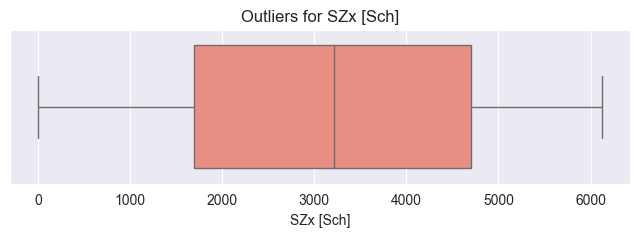

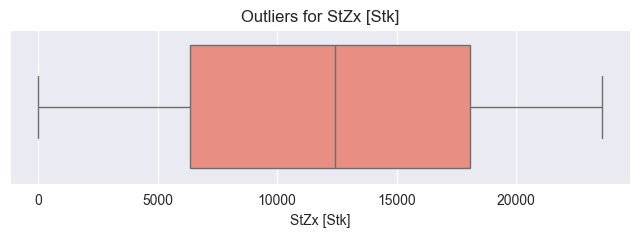

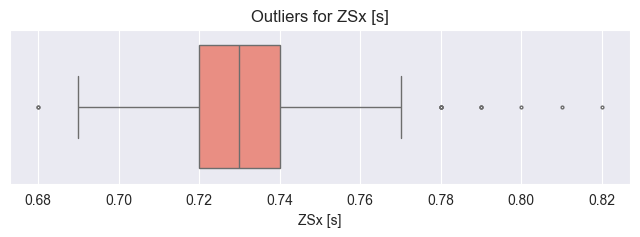

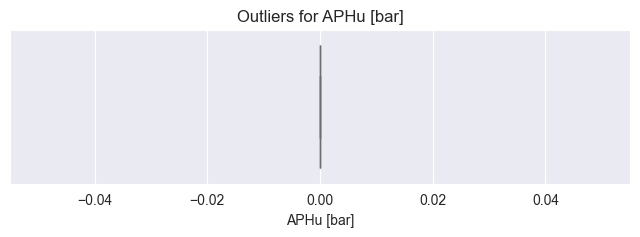

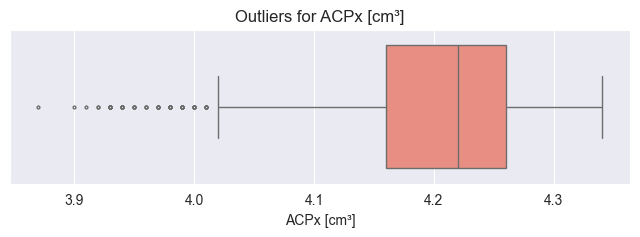

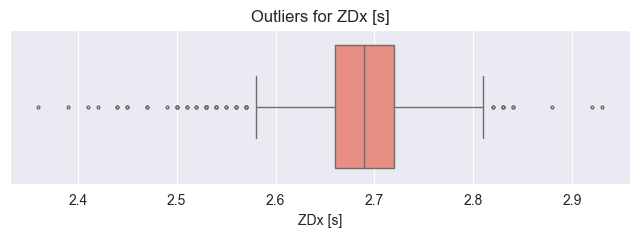

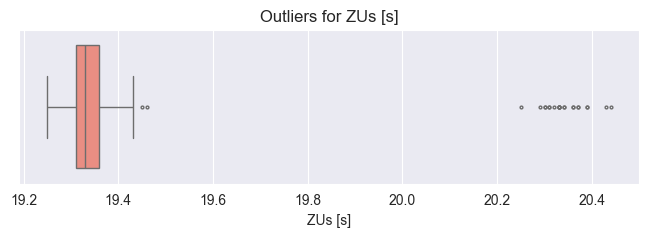

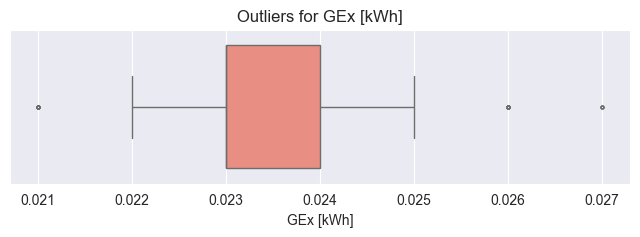

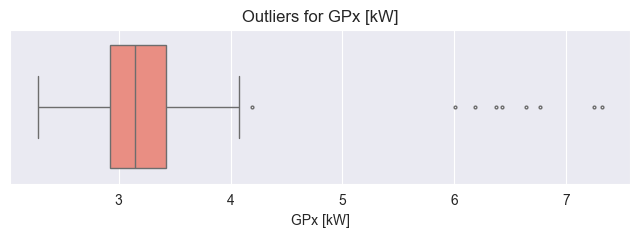

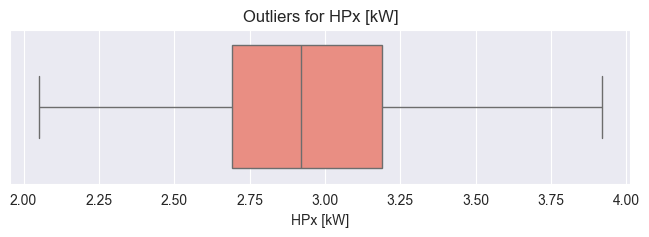

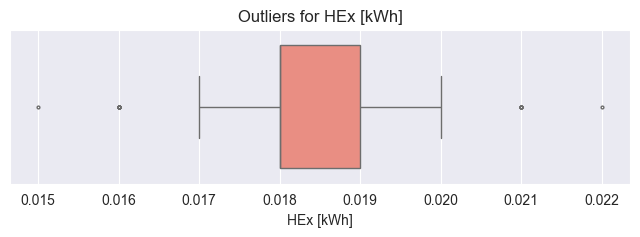

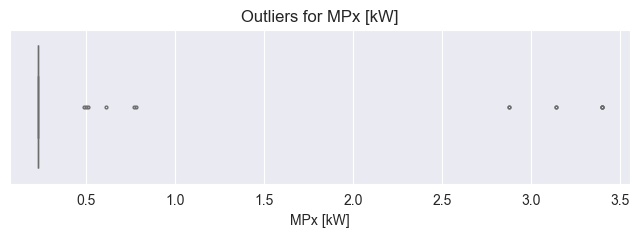

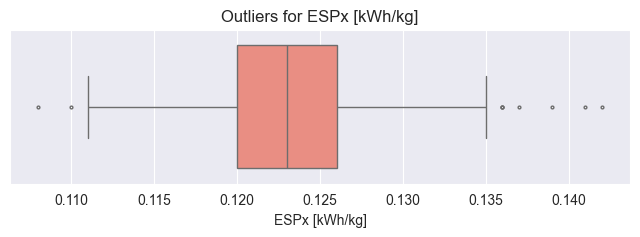

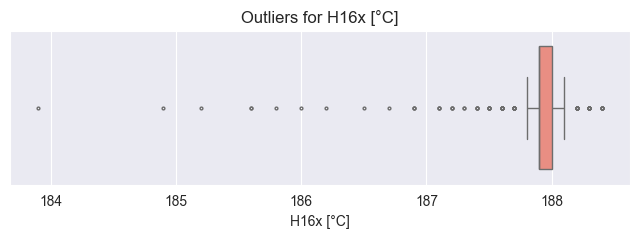

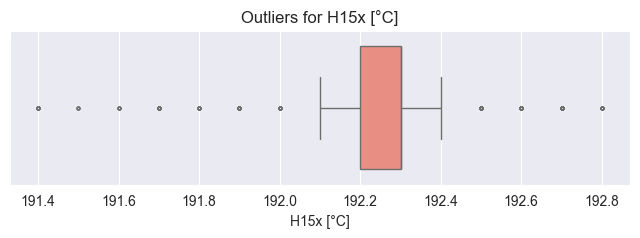

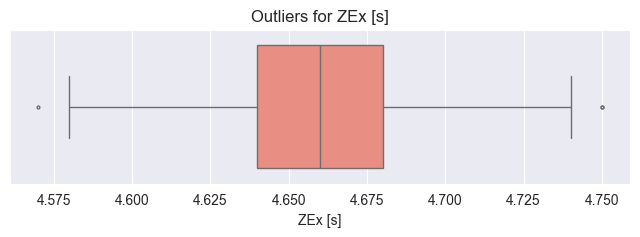

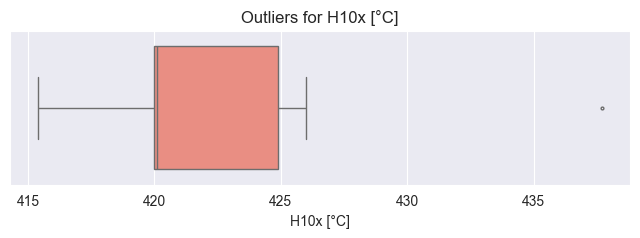

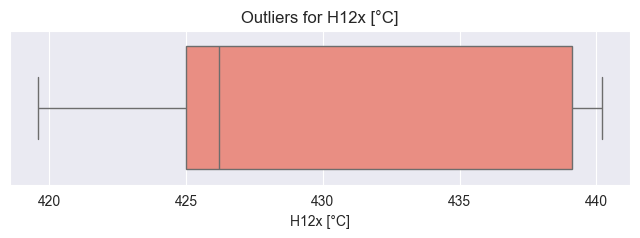

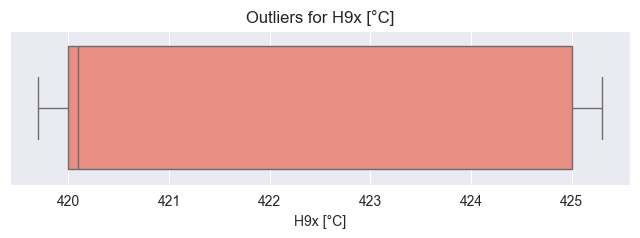

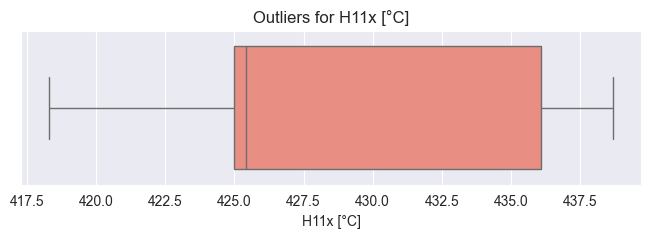

In [35]:
def plot_outliers(dataset):
    numeric_cols = dataset.select_dtypes(include=[np.number])

    cols = numeric_cols.columns
    cols_per_row = 3
    num_plots = len(numeric_cols)
    rows = math.ceil(num_plots / cols_per_row)

    for col in numeric_cols.columns:
        pyplt.figure(figsize=(8, 2))
        sns.boxplot(x=numeric_cols[col], color='salmon', fliersize=2)

        pyplt.title(f'Outliers for {col}')
        pyplt.show()

        pyplt.close()



plot_outliers(dataset)

#### Filtering out obvious sensor glitches ####

Certain anomalous datapoints were noticed in the Z-score analysis. In short, we can state a few basic tenets of operation for the machine:
1. The cycle time ZUs cannot be minutely small.
2. The dosing time ZDx must be non-zero. i.e., every shot must melt plastic.
3. The energy consumption ESPx must be not close to zero. i.e., every shot must use energy.


We encounter the dilemma here of how to navigate these anomalies. Which points are caused by sensor / logging errors and which are symptoms of a failed part?

We choose to statistically trim control variables like cycle time (ZUs) and dosing time (ZDx) using a percentile filter. This eliminates noise while preserving some anomalous events. Then there will be some physical logic filters for the aforementioned tenets.



In [36]:
# Check the difference for Cycle Time
col = 'ZUs [s]'
print(f"Original Max: {dataset[col].max()}")
print(f"99.9th Percentile (0.1% trim): {dataset[col].quantile(0.999)}")
print(f"99.5th Percentile (0.5% trim): {dataset[col].quantile(0.995)}")

Original Max: 20.44
99.9th Percentile (0.1% trim): 20.433880000000002
99.5th Percentile (0.5% trim): 20.3888


In [37]:
# Do extreme cycle times correlate with failures?
upper_threshold = dataset['ZUs [s]'].quantile(0.99)
extreme_data = dataset[dataset['ZUs [s]'] > upper_threshold]
normal_data = dataset[dataset['ZUs [s]'] <= upper_threshold]

print(f"Scrap Rate in Extremes: {extreme_data['ASZ [Sch].1'].mean()}")
print(f"Scrap Rate in Normal: {normal_data['ASZ [Sch].1'].mean()}")

KeyError: 'ASZ [Sch].1'

The scrap rate in normal is higher than in the extremes, meaning the upper percentiles of the cycle time are not driving failures. We don't want the machine to falsely make the assumption that longer cycle time equals lower scrap. However, we also want to get rid of values on the low end such as the 0.88s cycle time. Hence, we filter asymmetrically, dropping the lower 0.5%

Additionally, we also drop the counter columns and date and time columns to prevent the ML model from overfitting on the shot count, or drawing any other illogical inferences.

In [38]:
def filter_outliers(dataset):
    dataset = dataset[dataset['ZDx [s]'] > 0.1]
    dataset = dataset[dataset['ZDx [s]'] < dataset['ZDx [s]'].quantile(0.999)]

    dataset = dataset[dataset['ZSx [s]'] >= dataset['ZSx [s]'].quantile(0.005)]

    dataset = dataset[dataset['ZUs [s]'] >= dataset['ZUs [s]'].quantile(0.005)]
    dataset = dataset[dataset['ZUs [s]'] <= dataset['ZUs [s]'].quantile(0.999)]

   # dataset = dataset.drop(columns=['SZx [Sch]', 'StZx [Stk]', 'Datum [ ]', 'Zeit [ ]', 'ASZ [Sch].1'])
    dataset = dataset.drop(columns=['StZx [Stk]', 'Datum [ ]', 'Zeit [ ]'])

    return dataset

dataset = filter_outliers(dataset)


#### Comparison of Filtered to Original Dataset ####

We compare the filtered to the virgin dataset to see if we were too aggressive with the filtering.

In [39]:
original_count = len(dataset_copy)
filtered_count = len(dataset)
loss_percentage = ((original_count - filtered_count) / original_count) * 100

print(f"Original Rows: {original_count}")
print(f"Filtered Rows: {filtered_count}")
print(f"Data Loss: {loss_percentage:.2f}%")

Original Rows: 613
Filtered Rows: 608
Data Loss: 0.82%


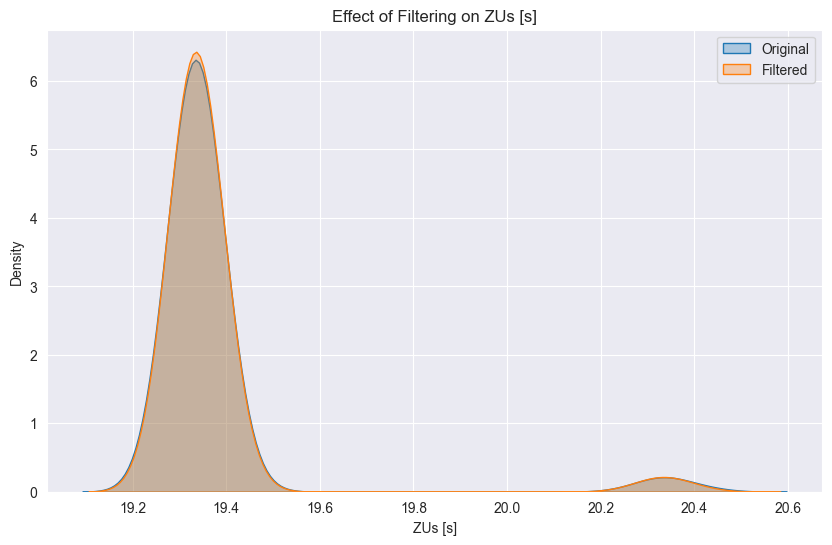

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

def compare_distributions(df_old, df_new, column):
    plt.figure(figsize=(10, 6))
    sns.kdeplot(df_old[column], label='Original', fill=True, alpha=0.3)
    sns.kdeplot(df_new[column], label='Filtered', fill=True, alpha=0.3)
    plt.title(f'Effect of Filtering on {column}')
    plt.legend()
    plt.show()

compare_distributions(dataset_copy, dataset, 'ZUs [s]')

In [41]:
comparison = pd.DataFrame({
    'Original Mean': dataset_copy.mean(numeric_only=True),
    'Filtered Mean': dataset.mean(numeric_only=True),
    'Diff %': ((dataset.mean(numeric_only=True) - dataset_copy.mean(numeric_only=True)) / dataset_copy.mean(numeric_only=True)) * 100
})
print(comparison.sort_values(by='Diff %', ascending=False))

               Original Mean  Filtered Mean    Diff %
SZx [Sch]        3176.845024    3181.574013  0.148858
MPx [kW]            0.272545       0.272895  0.128374
GPx [kW]            3.212659       3.213388  0.022695
ZSx [s]             0.728157       0.728306  0.020506
HPx [kW]            2.940098       2.940477  0.012894
H12x [°C]         431.317292     431.372039  0.012693
H11x [°C]         429.485481     429.536842  0.011959
GEx [kWh]           0.023519       0.023520  0.004153
ESPx [kWh/kg]       0.123263       0.123263  0.000418
H15x [°C]         192.267700     192.268257  0.000290
H9x [°C]          421.986134     421.986184  0.000012
H16x [°C]         187.901468     187.901316 -0.000081
H10x [°C]         422.002773     422.002138 -0.000150
ZEx [s]             4.661289       4.661102 -0.004007
HEx [kWh]           0.018261       0.018260 -0.006259
ZUs [s]            19.371713      19.370428 -0.006635
ACPx [cm³]          4.191011       4.190609 -0.009613
ZDx [s]             2.684747

The filtering seems to have been done well. Data loss is 0.86% meaning I did not viciously gut the dataset, but merely removed 42 rows of noise. The scrap count (ASZ [Sch].1) only went down by 0.11%, meaning the rows I deleted were not the primary source of the part failures. All the important information is still in the filtered dataset.

ZSx (injection time) and MPx saw the largest drops, confirming the removal of the previously observed ghosting.

## Chapter 2: Encoding and Scaling ##

#### Binary Encoding of ASZ [Sch] ####

In [42]:
dataset['ASZ [Sch]'] = (dataset['ASZ [Sch]'] == '*').astype(int)

print(dataset['ASZ [Sch]'].value_counts())

KeyError: 'ASZ [Sch]'

#### Feature Scaling ####

Scaling is left as an exercise to the reader. It is to be implemented within your individual models.

### Dataframe Export ###

In [44]:
output_dir = 'intermediate'
file_name = 'CLEAN_eval_set_1_no_target.csv'

file_path = os.path.join(output_dir, file_name)
dataset.to_csv(file_path, index=False)

print("File saved")

File saved
